In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vpapenko/nails-segmentation")

print("Path to dataset files:", path)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /root/.cache/kagglehub/datasets/vpapenko/nails-segmentation/versions/1


In [2]:
!cp -r /root/.cache/kagglehub/datasets/vpapenko/nails-segmentation/versions/1 .

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import numpy as np
from sklearn.metrics import f1_score

In [4]:
class NailsDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None, image_extensions=['.jpg', '.jpeg', '.png']):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform
        self.image_extensions = image_extensions

        # Собираем только файлы с указанными расширениями
        self.image_names = [
            fname for fname in os.listdir(image_dir)
            if os.path.isfile(os.path.join(image_dir, fname)) and fname.lower().endswith(tuple(image_extensions))
        ]

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.image_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name)

        # Загружаем изображение и маску
        image = Image.open(img_path).convert("RGB")  # Убедимся, что изображение в RGB
        label = Image.open(label_path).convert("L")  # Убедимся, что маска в градациях серого

        if self.transform:
            image = self.transform(image)
            # Применяем трансформации к маске, но не нормализуем
            label = self.transform(label)

        # Преобразуем маску в бинарную (0 или 1)
        label = (label > 0.5).float()  # Порог 127 для значений [0, 255]

        return image, label

In [5]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 128x128
    transforms.ToTensor(),          # Convert images to PyTorch tensors
])

In [6]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            )

        def up_conv(in_channels, out_channels):
            return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

        self.encoder1 = conv_block(3, 64)
        self.encoder2 = conv_block(64, 128)
        self.encoder3 = conv_block(128, 256)
        self.encoder4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = conv_block(512, 1024)

        self.upconv4 = up_conv(1024, 512)
        self.decoder4 = conv_block(1024, 512)
        self.upconv3 = up_conv(512, 256)
        self.decoder3 = conv_block(512, 256)
        self.upconv2 = up_conv(256, 128)
        self.decoder2 = conv_block(256, 128)
        self.upconv1 = up_conv(128, 64)
        self.decoder1 = conv_block(128, 64)

        # Изменен выход, теперь два канала
        self.final_conv = nn.Conv2d(64, 2, kernel_size=1)  # 2 канала для фона и объекта

    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool(enc1))
        enc3 = self.encoder3(self.pool(enc2))
        enc4 = self.encoder4(self.pool(enc3))

        bottleneck = self.bottleneck(self.pool(enc4))

        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)

        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)

        return self.final_conv(dec1)

In [7]:
# Функция для подсчёта весов классов
def compute_class_weights(dataset):
    count_0, count_1 = 0, 0

    for img, mask in dataset:
        mask_np = mask.numpy()  # Преобразуем маску в numpy array
        count_0 += np.sum(mask_np == 0)
        count_1 += np.sum(mask_np == 1)

    total_pixels = count_0 + count_1
    freq_0 = count_0 / total_pixels
    freq_1 = count_1 / total_pixels

    weight_0 = 1 / freq_0
    weight_1 = 1 / freq_1

    return torch.tensor([weight_0, weight_1], dtype=torch.float32)

In [8]:
dataset = NailsDataset(image_dir='1/nails_segmentation/images', label_dir='1/nails_segmentation/labels', transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [9]:
class_weights = compute_class_weights(dataset)
print("Class Weights:", class_weights)

# Передаём веса в функцию потерь
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

Class Weights: tensor([ 1.0511, 20.5650])


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

# Взвешенная функция потерь
#class_weights = torch.tensor([1.0, 10.0]).to(device)  # Белому классу даем больший вес
#criterion = nn.BCELoss(weight=class_weights)
#optimizer = optim.Adam(model.parameters(), lr=0.001)

# Используем CrossEntropyLoss для многоклассовой сегментации
#criterion = nn.CrossEntropyLoss(weight=class_weights)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

# Взвешенная функция потерь
#class_weights = torch.tensor([1.0, 4.0]).to(device)  # Белому классу даем больший вес
class_weights = compute_class_weights(dataset).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    epoch_f1 = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        outputs = torch.sigmoid(outputs).float()

        labels = (labels > 0.5).long()  
        if len(labels.shape) == 4:  
            labels = labels.squeeze(1)


        # Вычисление потерь
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Вычисление F1 score для оценки качества модели
        predicted = torch.argmax(outputs, dim=1)  # Применяем argmax для многоклассовой сегментации
        f1 = f1_score(labels.cpu().numpy().flatten(), predicted.cpu().numpy().flatten(), average='binary')
        epoch_f1 += f1

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss / len(train_loader):.4f}, F1 Score: {epoch_f1 / len(train_loader):.4f}")

Epoch [1/100], Loss: 0.6918, F1 Score: 0.0000
Epoch [2/100], Loss: 0.6911, F1 Score: 0.0000
Epoch [3/100], Loss: 0.6908, F1 Score: 0.0000
Epoch [4/100], Loss: 0.6902, F1 Score: 0.0000
Epoch [5/100], Loss: 0.6879, F1 Score: 0.1111
Epoch [6/100], Loss: 0.6832, F1 Score: 0.1422
Epoch [7/100], Loss: 0.6789, F1 Score: 0.1372
Epoch [8/100], Loss: 0.6698, F1 Score: 0.1484
Epoch [9/100], Loss: 0.6580, F1 Score: 0.1243
Epoch [10/100], Loss: 0.6436, F1 Score: 0.1773
Epoch [11/100], Loss: 0.6277, F1 Score: 0.1465
Epoch [12/100], Loss: 0.6247, F1 Score: 0.2087
Epoch [13/100], Loss: 0.6043, F1 Score: 0.1375
Epoch [14/100], Loss: 0.6098, F1 Score: 0.1522
Epoch [15/100], Loss: 0.5882, F1 Score: 0.1700
Epoch [16/100], Loss: 0.5879, F1 Score: 0.1363
Epoch [17/100], Loss: 0.5786, F1 Score: 0.1704
Epoch [18/100], Loss: 0.6098, F1 Score: 0.1649
Epoch [19/100], Loss: 0.5836, F1 Score: 0.1703
Epoch [20/100], Loss: 0.5918, F1 Score: 0.1488
Epoch [21/100], Loss: 0.5637, F1 Score: 0.1508
Epoch [22/100], Loss: 

In [12]:
def calculate_iou(preds, labels):
    # Применяем порог к предсказаниям (0.5)
    preds = (preds > 0.5).float()
    
    # Вычисляем Intersection и Union
    intersection = (preds * labels).sum()
    union = preds.sum() + labels.sum() - intersection
    
    # Избегаем деления на ноль
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()
model.eval()
total_iou = 0
num_batches = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        # Вычисляем IoU для текущего батча
        batch_iou = calculate_iou(outputs, labels)
        total_iou += batch_iou
        num_batches += 1

# Средний IoU по всем батчам
mean_iou = total_iou / num_batches
print(f"Mean IoU on test set: {mean_iou:.4f}")

Mean IoU on test set: 0.0470


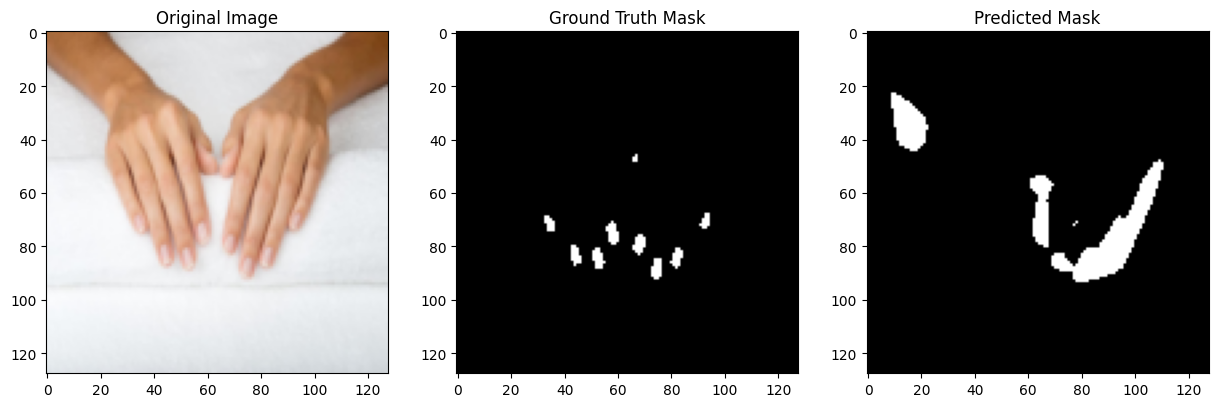

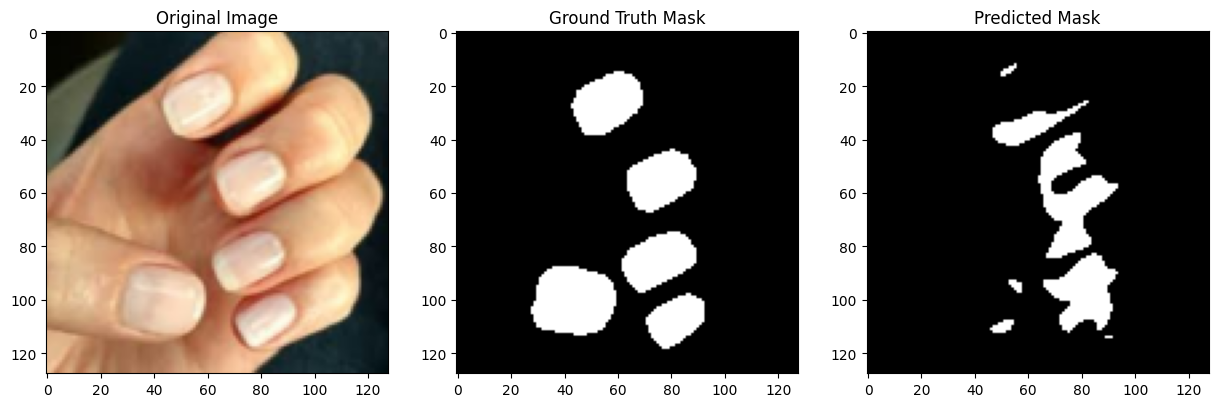

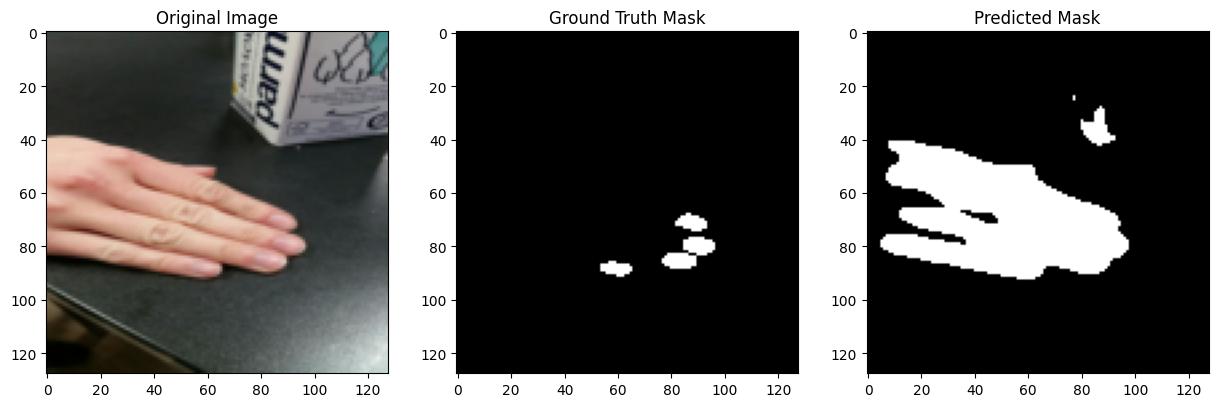

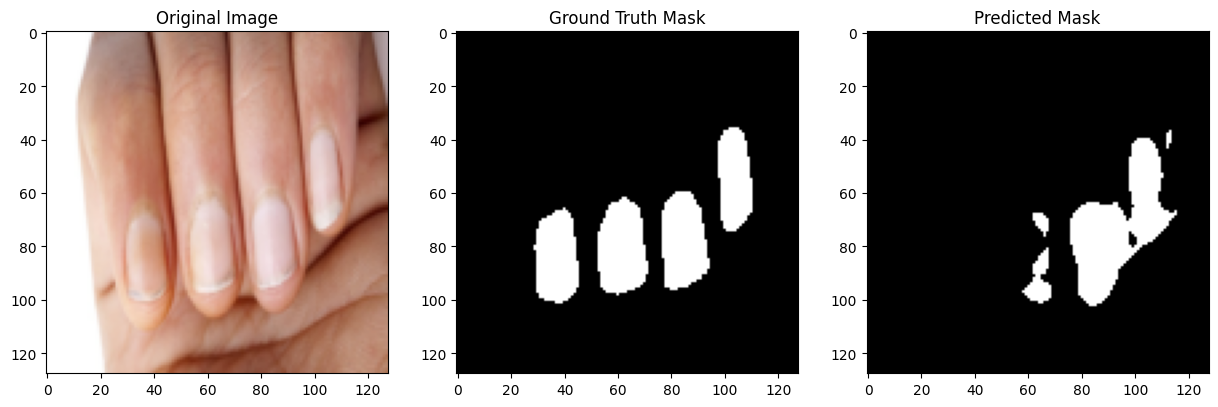

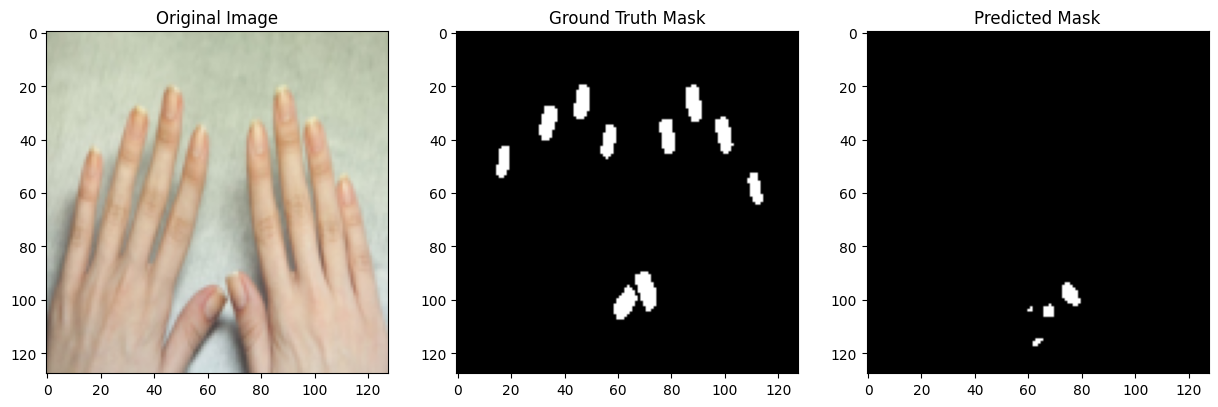

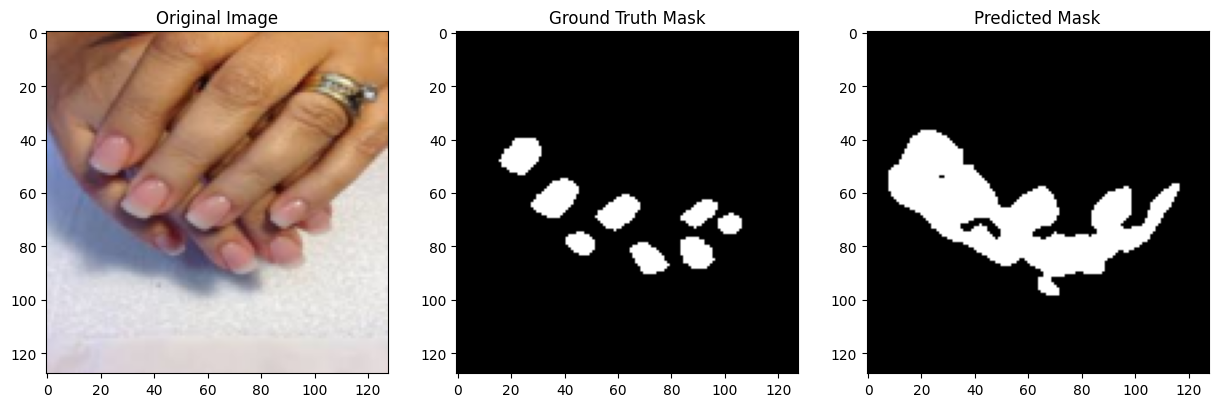

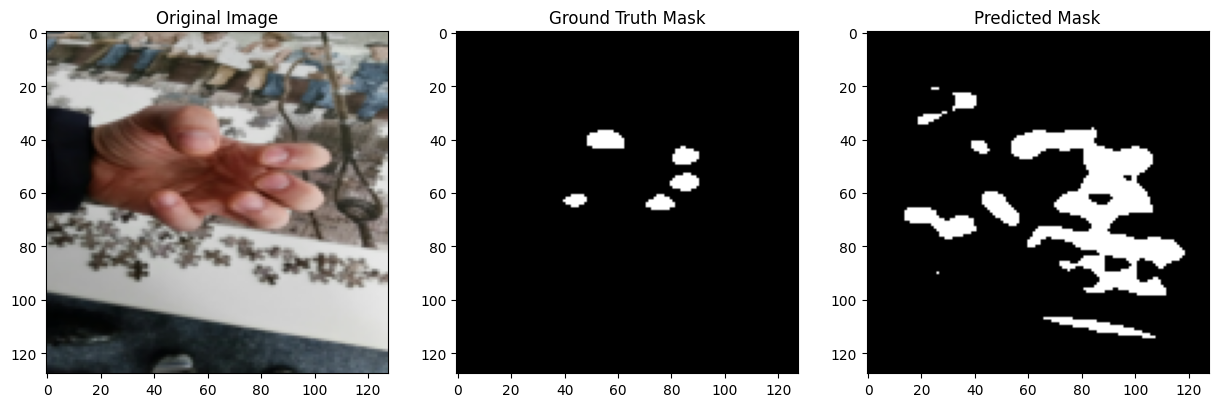

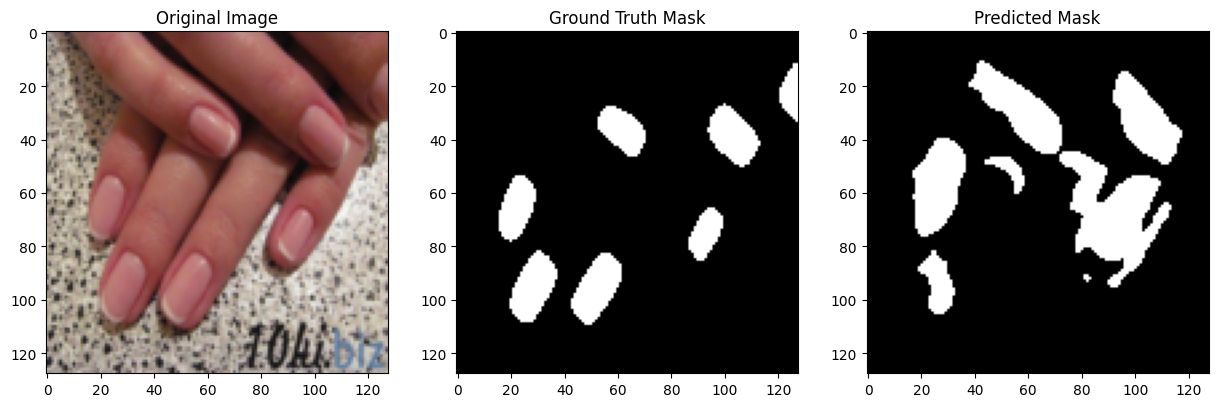

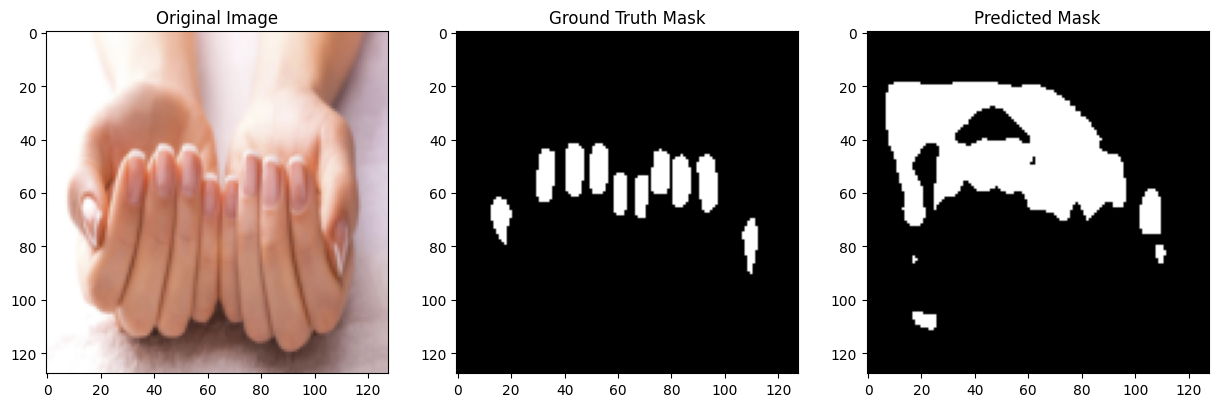

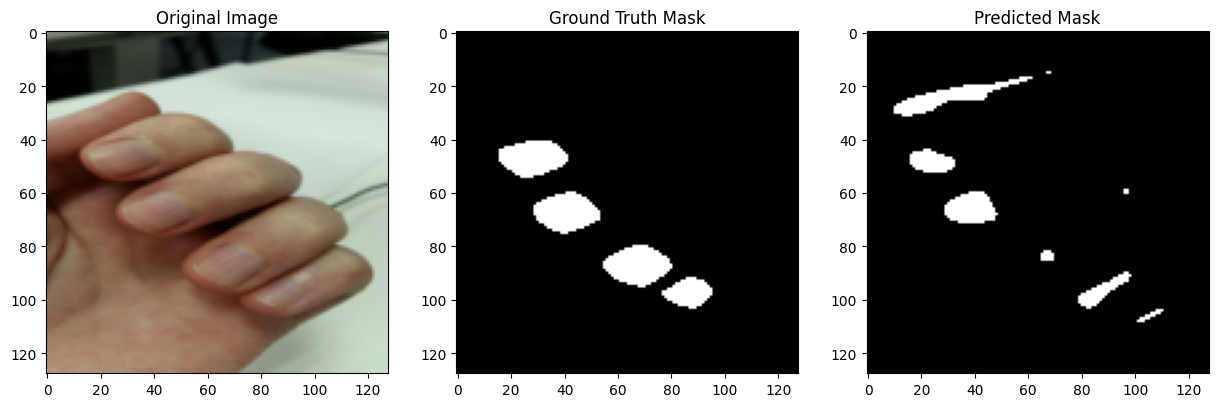

In [15]:
import matplotlib.pyplot as plt
import random

# Выбираем случайные индексы для визуализации
indices = random.sample(range(len(test_dataset)), 10)

model.eval()
with torch.no_grad():
    for idx in indices:
        image, label = test_dataset[idx]
        image = image.unsqueeze(0).to(device)  # Добавляем batch dimension
        output = model(image)
        
        # Применяем порог к предсказаниям
        output = (output > 0.5).float()
        
        # Переводим тензоры в numpy для визуализации
        image = image.squeeze().cpu().permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)
        label = label.squeeze().cpu().numpy()
        #output = output.squeeze().cpu().numpy()
        output = output.squeeze().cpu().numpy()

# Если output имеет 2 канала, выбираем только один (обычно класс 1)
        if output.ndim == 3:  # Проверяем, есть ли у тензора 3 измерения (C, H, W)
            output = output[1]
        
        # Визуализация
        plt.figure(figsize=(15, 5))
        
        # Оригинальное изображение
        plt.subplot(1, 3, 1)
        plt.title("Original Image")
        plt.imshow(image)
        
        # Маска (лейбл)
        plt.subplot(1, 3, 2)
        plt.title("Ground Truth Mask")
        plt.imshow(label, cmap='gray')
        
        # Предсказание модели
        plt.subplot(1, 3, 3)
        plt.title("Predicted Mask")
        plt.imshow(output, cmap='gray')
        
        plt.show()

In [20]:
sample_image, sample_label = dataset[0]

# Проверка изображения
print(f"Image shape: {sample_image.shape}")
print(f"Image min: {sample_image.min().item()}, Image max: {sample_image.max().item()}")

# Проверка маски
print(f"Label shape: {sample_label.shape}")
print(f"Label min: {sample_label.min().item()}, Label max: {sample_label.max().item()}")

Image shape: torch.Size([3, 128, 128])
Image min: 0.08235294371843338, Image max: 0.9607843160629272
Label shape: torch.Size([1, 128, 128])
Label min: 0.0, Label max: 1.0


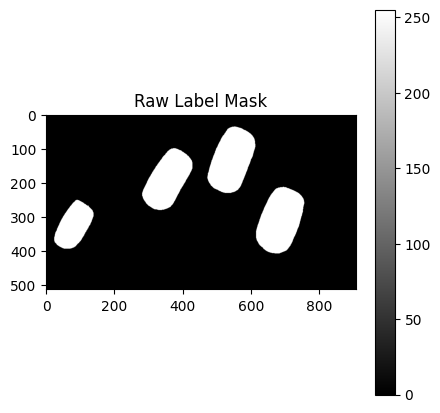

Label unique values: [  0   1   2 254 255]
Label min: 0, Label max: 255


In [12]:
# Загружаем маску без трансформаций
label_path = os.path.join(dataset.label_dir, dataset.image_names[0])
label = Image.open(label_path).convert("L")  # Убедимся, что маска в градациях серого

# Визуализация
plt.figure(figsize=(5, 5))
plt.title("Raw Label Mask")
plt.imshow(label, cmap='gray')
plt.colorbar()
plt.show()

# Проверка значений пикселей
label_array = np.array(label)
print(f"Label unique values: {np.unique(label_array)}")
print(f"Label min: {label_array.min()}, Label max: {label_array.max()}")